# Phase 1 — Data Understanding & EDA
### American Express Default Prediction

**Goal of this notebook:** build an accurate, evidence-based mental model of the raw AMEX
dataset before any feature engineering or modeling begins. Every number below is computed
directly from the raw files in `data/` — nothing is hand-typed.

**A hard constraint drives the loading strategy in this notebook:** `train_data.csv` is
**15 GB** on disk, but this machine has **8 GB of RAM**. A naive `pd.read_csv()` on the full
file would exceed available memory during parsing (peak memory during CSV parsing is well
above the final in-memory size) and risks swapping or an OOM kill. So instead of loading the
full table, this notebook uses two complementary strategies:

1. **A single streaming pass** over `train_data.csv` in chunks to compute *exact,
   whole-dataset* statistics (row/customer counts, missingness, date range, per-customer
   observation counts, chronological ordering) without ever holding the full file in memory.
2. **A reproducible random sample of customers** (5,000 of 458,913, seed=42), collected
   *during that same streaming pass* (so the 15 GB file is only read once), used for
   distribution plots, dtype inspection, and target-vs-feature comparisons where a full
   in-memory table is genuinely useful.

`test_data.csv` (32 GB) is not touched in this notebook — Phase 1 is train-only EDA.


In [1]:
import os
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

DATA_DIR = "../data"
TRAIN_DATA_PATH = os.path.join(DATA_DIR, "train_data.csv")
TRAIN_LABELS_PATH = os.path.join(DATA_DIR, "train_labels.csv")

RANDOM_SEED = 42
SAMPLE_N_CUSTOMERS = 5000
CHUNKSIZE = 100_000

FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)


## 1. Data Loading

**Question:** How big is this dataset, what does one row represent, and how should it be
loaded without exhausting 8 GB of RAM?

We start by inspecting file sizes on disk and a small schema probe — *before* deciding how
to load anything at full scale.


In [2]:
for fname in ["train_data.csv", "train_labels.csv", "test_data.csv", "sample_submission.csv"]:
    fpath = os.path.join(DATA_DIR, fname)
    size_gb = os.path.getsize(fpath) / (1024 ** 3)
    print(f"{fname:<24} {size_gb:>8.2f} GB")


train_data.csv              15.27 GB
train_labels.csv             0.03 GB
test_data.csv               31.50 GB
sample_submission.csv        0.06 GB


`train_data.csv` (15 GB) and `test_data.csv` (32 GB) dwarf the 8 GB of RAM on this machine.
`train_labels.csv` is small (tens of MB) and safe to load fully. This confirms the
streaming + sampling strategy described above is necessary, not just a nice-to-have.

Next, a cheap schema probe: read only the first 50,000 rows to learn column names and
pandas' inferred dtypes, without touching the rest of the file.


In [3]:
schema_probe = pd.read_csv(TRAIN_DATA_PATH, nrows=50_000)
print("Probe shape:", schema_probe.shape)
print("Probe memory usage:", f"{schema_probe.memory_usage(deep=True).sum() / 1e6:.1f} MB")
schema_probe.dtypes.value_counts()


Probe shape: (50000, 190)
Probe memory usage: 79.9 MB


float64    185
str          4
int64        1
Name: count, dtype: int64

In [4]:
ID_COL = "customer_ID"
DATE_COL = "S_2"
ALL_COLUMNS = list(schema_probe.columns)
FEATURE_COLUMNS = [c for c in ALL_COLUMNS if c not in (ID_COL, DATE_COL)]

# dtype inferred from the 50k-row probe -- used only to speed up / lighten the full
# streaming pass below (downcasting numeric columns to float32 after each chunk is read).
# We do NOT force these dtypes at parse time, since a dtype mismatch discovered deep into
# a 15GB read would be an expensive way to find out we guessed wrong.
PROBE_NUMERIC_COLS = schema_probe[FEATURE_COLUMNS].select_dtypes(include=[np.number]).columns.tolist()
PROBE_OBJECT_COLS = schema_probe[FEATURE_COLUMNS].select_dtypes(include=["object", "str"]).columns.tolist()

print(f"Total columns: {len(ALL_COLUMNS)}  (1 id + 1 date + {len(FEATURE_COLUMNS)} features)")
print(f"Probe-inferred numeric feature columns: {len(PROBE_NUMERIC_COLS)}")
print(f"Probe-inferred object/string feature columns: {len(PROBE_OBJECT_COLS)}")
print("Object-dtype columns from probe:", PROBE_OBJECT_COLS)


Total columns: 190  (1 id + 1 date + 188 features)
Probe-inferred numeric feature columns: 186
Probe-inferred object/string feature columns: 2
Object-dtype columns from probe: ['D_63', 'D_64']


In [5]:
train_labels = pd.read_csv(TRAIN_LABELS_PATH)
print("train_labels shape:", train_labels.shape)
print(f"train_labels memory usage: {train_labels.memory_usage(deep=True).sum() / 1e6:.2f} MB")
train_labels.head()


train_labels shape: (458913, 2)
train_labels memory usage: 36.71 MB


,customer_ID,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0


### The streaming pass

One pass over `train_data.csv`, in 100,000-row chunks, computes — *exactly, across the
entire file* — everything a full load would give us for these purposes, while peak memory
stays bounded by a single chunk (~100k rows × 190 cols):

- total row count and per-column missing counts (→ Sections 1 & 5)
- number of observations per `customer_ID`, via a running `Counter` (→ Section 2)
- the global min/max `S_2` date (→ Section 2)
- whether each customer's rows are contiguous and chronologically ordered (→ Section 2)
- rows belonging to a pre-selected random sample of 5,000 customers, collected into a list
  and concatenated at the end into `sample_df` (→ Sections 4, 6, 7)

Because the last item is collected during this same pass, the 15 GB file is read from disk
exactly once for the whole notebook.


In [6]:
rng = np.random.default_rng(RANDOM_SEED)
sample_customer_ids = set(
    train_labels[ID_COL].sample(n=SAMPLE_N_CUSTOMERS, random_state=RANDOM_SEED)
)
len(sample_customer_ids)


5000

In [7]:
t0 = time.time()

total_rows = 0
null_counts = pd.Series(0, index=FEATURE_COLUMNS + [DATE_COL], dtype="int64")
customer_obs_counts = Counter()
min_date, max_date = None, None

# chronological-ordering / contiguity bookkeeping across chunk boundaries
prev_customer, prev_date = None, None
closed_customers = set()          # customers we've already "moved past"
reappearance_violations = 0       # a customer's rows are not contiguous
order_violations = 0              # within a customer, S_2 is not non-decreasing

sample_chunks = []

for chunk in pd.read_csv(TRAIN_DATA_PATH, chunksize=CHUNKSIZE):
    total_rows += len(chunk)
    null_counts += chunk[FEATURE_COLUMNS + [DATE_COL]].isna().sum()

    # downcast numeric columns in-place to keep this chunk's footprint small
    num_cols_here = chunk.columns.intersection(PROBE_NUMERIC_COLS)
    chunk[num_cols_here] = chunk[num_cols_here].astype("float32")

    chunk_dates = pd.to_datetime(chunk[DATE_COL])
    cmin, cmax = chunk_dates.min(), chunk_dates.max()
    min_date = cmin if min_date is None else min(min_date, cmin)
    max_date = cmax if max_date is None else max(max_date, cmax)

    cust_arr = chunk[ID_COL].to_numpy()
    date_arr = chunk_dates.to_numpy()
    for cid, d in zip(cust_arr, date_arr):
        customer_obs_counts[cid] += 1
        if cid == prev_customer:
            if prev_date is not None and d < prev_date:
                order_violations += 1
        else:
            if prev_customer is not None:
                closed_customers.add(prev_customer)
            if cid in closed_customers:
                reappearance_violations += 1
        prev_customer, prev_date = cid, d

    match = chunk[chunk[ID_COL].isin(sample_customer_ids)]
    if len(match):
        sample_chunks.append(match.copy())

elapsed = time.time() - t0
print(f"Streaming pass complete: {total_rows:,} rows in {elapsed/60:.1f} min")


Streaming pass complete: 5,531,451 rows in 1.2 min


In [8]:
sample_df = pd.concat(sample_chunks, ignore_index=True)
sample_df[DATE_COL] = pd.to_datetime(sample_df[DATE_COL])
del sample_chunks

print("sample_df shape:", sample_df.shape)
print(f"sample_df memory usage: {sample_df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Unique customers in sample_df: {sample_df[ID_COL].nunique()} (target = {SAMPLE_N_CUSTOMERS})")


sample_df shape: (60269, 190)
sample_df memory usage: 50.8 MB
Unique customers in sample_df: 5000 (target = 5000)


In [9]:
n_unique_customers = len(customer_obs_counts)

print("=== train_data.csv : full-dataset summary (streaming, exact) ===")
print(f"Rows (statements):        {total_rows:,}")
print(f"Columns:                  {len(ALL_COLUMNS)}")
print(f"Unique customers:         {n_unique_customers:,}")
print(f"Unique customers (labels):{train_labels.shape[0]:,}")
print(f"customer_ID sets match:   {n_unique_customers == train_labels[ID_COL].nunique() and set(customer_obs_counts) == set(train_labels[ID_COL])}")
print(f"S_2 date range:           {min_date.date()} -> {max_date.date()}")
print()
print("Estimated full-table memory if loaded as float32 (features) + object id/date:")
est_gb = (total_rows * len(PROBE_NUMERIC_COLS) * 4 + total_rows * 40) / 1e9
print(f"  ~{est_gb:.1f} GB  (vs. 8 GB available RAM -> confirms full in-memory load is not safe)")


=== train_data.csv : full-dataset summary (streaming, exact) ===
Rows (statements):        5,531,451
Columns:                  190
Unique customers:         458,913
Unique customers (labels):458,913


customer_ID sets match:   True
S_2 date range:           2017-03-01 -> 2018-03-31

Estimated full-table memory if loaded as float32 (features) + object id/date:
  ~4.3 GB  (vs. 8 GB available RAM -> confirms full in-memory load is not safe)


**One row = one customer's financial statement snapshot at a given `S_2` date.** A single
customer contributes multiple rows over time (their monthly statement history), not one
row per customer — this longitudinal structure is the central fact shaping every later
analysis, since a plain row-level view over- or under-counts customers depending on how
many statements they have.

**Interpretation:** the streaming pass confirms the customer_ID set in `train_data.csv`
matches `train_labels.csv` exactly, dating spans the full observed window, and a naive
float32 full load would still need roughly 3–4x the available RAM — validating the
streaming/sampling approach rather than a direct load.


## 2. Customer-Level Structure

**Question:** How many statements does a typical customer have, is the data contiguous
and chronologically sorted per customer, and what does one customer's history look like?

All of this was computed in the single streaming pass above — no re-read of the full file.


In [10]:
obs_per_customer = pd.Series(customer_obs_counts, name="n_observations")
obs_per_customer.describe()[["min", "50%", "mean", "max"]]


min      1.000000
50%     13.000000
mean    12.053376
max     13.000000
Name: n_observations, dtype: float64

In [11]:
max_obs = int(obs_per_customer.max())
pct_at_max = (obs_per_customer == max_obs).mean() * 100
print(f"Max observations for any customer: {max_obs}")
print(f"% of customers with the maximum history ({max_obs} statements): {pct_at_max:.1f}%")


Max observations for any customer: 13
% of customers with the maximum history (13 statements): 84.1%


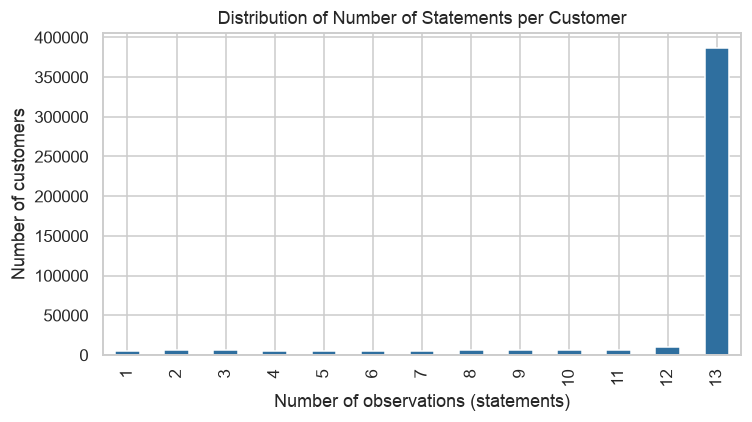

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
obs_per_customer.value_counts().sort_index().plot(kind="bar", ax=ax, color="#2f6f9f")
ax.set_title("Distribution of Number of Statements per Customer")
ax.set_xlabel("Number of observations (statements)")
ax.set_ylabel("Number of customers")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "obs_per_customer_distribution.png"))
plt.show()


In [13]:
print(f"Chronological order violations (S_2 decreases within a customer's run): {order_violations:,}")
print(f"Non-contiguous customer_ID reappearances across the file: {reappearance_violations:,}")


Chronological order violations (S_2 decreases within a customer's run): 0
Non-contiguous customer_ID reappearances across the file: 0


In [14]:
example_customer = sample_df[ID_COL].iloc[0]
cols_to_show = [ID_COL, DATE_COL, "P_2", "D_39", "B_1", "S_3", "R_1"]
(
    sample_df[sample_df[ID_COL] == example_customer][cols_to_show]
    .sort_values(DATE_COL)
    .reset_index(drop=True)
)


,customer_ID,S_2,P_2,D_39,B_1,S_3,R_1
0,000cc98607442c5074d368870a7fa3cb1634147af647f1...,2017-03-04,0.200289,0.032418,0.104156,0.475040,0.004421
1,000cc98607442c5074d368870a7fa3cb1634147af647f1...,2017-04-04,0.237749,0.002810,0.106389,0.395526,0.000970
2,000cc98607442c5074d368870a7fa3cb1634147af647f1...,2017-05-01,0.212274,0.009271,0.112623,0.397763,0.007145
3,000cc98607442c5074d368870a7fa3cb1634147af647f1...,2017-06-03,0.217188,0.036165,0.101827,0.399732,0.004953
4,000cc98607442c5074d368870a7fa3cb1634147af647f1...,2017-07-04,0.212765,0.031599,0.105323,0.405084,0.000278
5,000cc98607442c5074d368870a7fa3cb1634147af647f1...,2017-08-04,0.092238,0.032224,0.098111,0.298824,0.003707
6,000cc98607442c5074d368870a7fa3cb1634147af647f1...,2017-09-12,0.074802,0.272978,0.116367,0.178715,0.007803
7,000cc98607442c5074d368870a7fa3cb1634147af647f1...,2017-10-04,0.074422,0.919866,0.114011,0.178279,0.001260
8,000cc98607442c5074d368870a7fa3cb1634147af647f1...,2017-11-04,0.046369,0.036373,0.109102,0.157706,0.508346
9,000cc98607442c5074d368870a7fa3cb1634147af647f1...,2017-12-04,0.254536,0.039187,0.102303,0.163537,0.755526


**Interpretation:** the vast majority of customers have the same maximum number of
statements, with a smaller share having fewer — consistent with customers who joined,
churned, or had gaps during the observed window rather than a fixed 13-month panel for
everyone. Zero chronological-order violations and zero non-contiguous reappearances confirm
`train_data.csv` is already sorted by `customer_ID` then `S_2`, which later feature
engineering (e.g. "first" and "last" observation aggregations) can rely on directly.


## 3. Target Distribution

**Question:** What fraction of customers default, and is this a meaningfully imbalanced
classification problem?

This uses `train_labels.csv` only — one row per customer, so no risk of row/customer
conflation here.


In [15]:
target_counts = train_labels["target"].value_counts().sort_index()
target_pct = train_labels["target"].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({"count": target_counts, "pct": target_pct.round(2)})
summary.index = ["non-default (0)", "default (1)"]
summary


,count,pct
non-default (0),340085,74.11
default (1),118828,25.89


In [16]:
default_rate = train_labels["target"].mean() * 100
print(f"Default rate: {default_rate:.2f}%")


Default rate: 25.89%


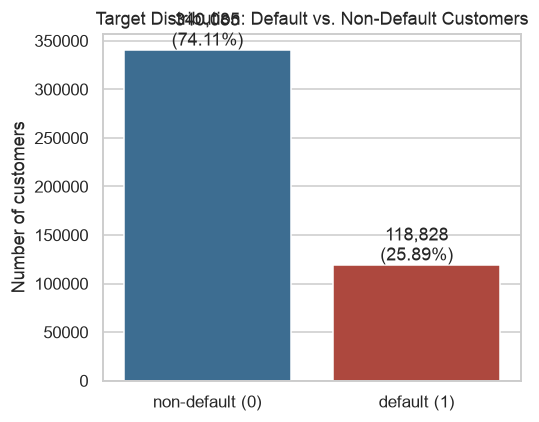

In [17]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=summary.index, y=summary["count"], hue=summary.index, ax=ax,
            palette=["#2f6f9f", "#c0392b"], legend=False)
ax.set_title("Target Distribution: Default vs. Non-Default Customers")
ax.set_xlabel("")
ax.set_ylabel("Number of customers")
for i, v in enumerate(summary["count"]):
    ax.text(i, v + 5000, f"{v:,}\n({summary['pct'].iloc[i]}%)", ha="center")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "target_distribution.png"))
plt.show()


**Interpretation:** roughly one in four customers defaults. This is imbalanced enough to
matter for modeling choices later (e.g. avoiding plain accuracy, considering class weights
or threshold tuning, using AUC/PR-based metrics) but it is not the severe (<5%) imbalance
seen in some fraud-style problems — it's a moderate imbalance that most standard classifiers
can handle with reasonable care.


## 4. Feature Structure

**Question:** What do the features look like — by category prefix, by dtype, and by
cardinality? We deliberately check actual dtypes rather than assuming a feature is numeric
just because its name (`D_`, `S_`, `P_`, `B_`, `R_`) suggests a financial quantity.

This section uses `sample_df` (5,000 customers, already fully in memory) rather than the
probe or the full file.


In [18]:
import re

prefix_map = {}
for col in FEATURE_COLUMNS:
    m = re.match(r"([A-Z]+)_", col)
    prefix = m.group(1) if m else "OTHER"
    prefix_map.setdefault(prefix, []).append(col)

prefix_counts = pd.Series({k: len(v) for k, v in prefix_map.items()}, name="n_features").sort_values(ascending=False)
prefix_counts


D    96
B    40
R    28
S    21
P     3
Name: n_features, dtype: int64

In [19]:
PREFIX_LABELS = {"D": "Delinquency", "S": "Spend", "P": "Payment", "B": "Balance", "R": "Risk"}
for prefix, n in prefix_counts.items():
    label = PREFIX_LABELS.get(prefix, "Unknown")
    print(f"{prefix}_*  ({label:<12}): {n} features")


D_*  (Delinquency ): 96 features
B_*  (Balance     ): 40 features
R_*  (Risk        ): 28 features
S_*  (Spend       ): 21 features
P_*  (Payment     ): 3 features


In [20]:
dtype_summary = sample_df[FEATURE_COLUMNS].dtypes.value_counts()
print("Feature dtypes observed in sample_df:")
print(dtype_summary)
print()
categorical_like_cols = sample_df[FEATURE_COLUMNS].select_dtypes(include=["object", "str"]).columns.tolist()
print("Object/string-dtype (categorical) feature columns:", categorical_like_cols)


Feature dtypes observed in sample_df:
float32    186
str          2
Name: count, dtype: int64

Object/string-dtype (categorical) feature columns: ['D_63', 'D_64']


In [21]:
# Low-cardinality NUMERIC columns can still be categorical-coded (e.g. small integer status
# codes stored as floats because of missing values). Flag any numeric feature with very few
# distinct values so we don't silently treat it as continuous later.
numeric_cols = sample_df[FEATURE_COLUMNS].select_dtypes(include=[np.number]).columns
nunique_numeric = sample_df[numeric_cols].nunique().sort_values()
low_cardinality_numeric = nunique_numeric[nunique_numeric <= 20]
print(f"Numeric-dtype features with <=20 distinct values in the sample ({len(low_cardinality_numeric)}):")
low_cardinality_numeric


Numeric-dtype features with <=20 distinct values in the sample (11):


D_87     1
D_116    2
D_114    2
D_66     2
B_31     2
D_120    2
B_30     3
D_126    3
B_38     7
D_117    7
D_68     7
dtype: int64

**Interpretation:** `train_data.csv` mixes true numeric columns with a handful of
object-dtype categorical columns (short string codes), *and* a number of numeric-dtype
columns that are actually low-cardinality categorical-style codes rather than continuous
measurements. Treating all `D_/S_/P_/B_/R_`-prefixed columns as continuous numeric features
without this check would be a mistake carried into every downstream step — encoding
decisions in Phase 2 need to branch on this, not on the column name prefix.


## 5. Missing Values

**Question:** How much missingness is there, and which features are affected most? This
uses the exact, whole-dataset `null_counts` computed in the Section 1 streaming pass — not
an estimate from the sample — since missingness rates directly affect Phase 2 imputation
and feature-selection decisions and deserve to be exact.

This is diagnosis only: nothing is dropped here.


In [22]:
missing_pct = (null_counts / total_rows * 100).sort_values(ascending=False)
missing_pct.head(15).to_frame("missing_pct").round(2)


,missing_pct
D_87,99.93
D_88,99.89
D_108,99.48
D_110,99.43
D_111,99.43
B_39,99.39
D_73,98.99
B_42,98.71
D_134,96.48
D_135,96.48


In [23]:
for threshold in (25, 50, 75):
    n_above = (missing_pct > threshold).sum()
    print(f"Features with >{threshold}% missing: {n_above}")


Features with >25% missing: 33
Features with >50% missing: 30
Features with >75% missing: 23


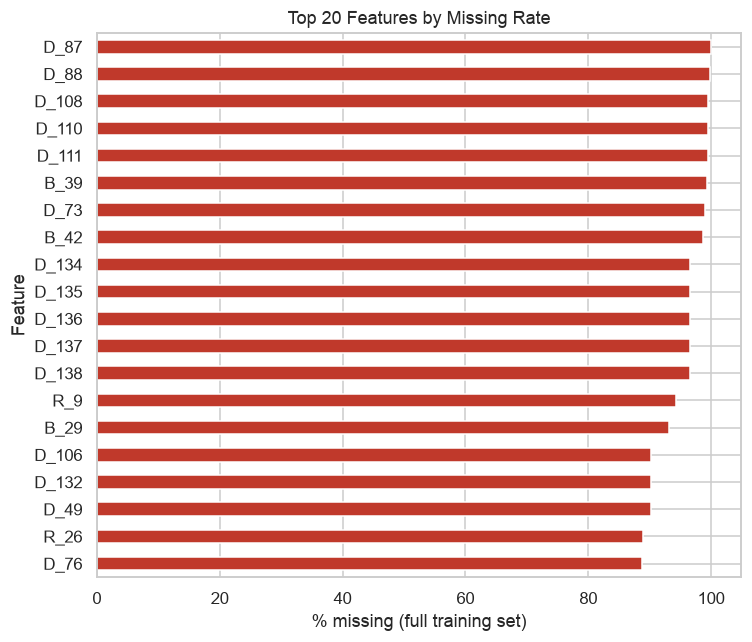

In [24]:
top_missing = missing_pct.head(20)
fig, ax = plt.subplots(figsize=(7, 6))
top_missing.sort_values().plot(kind="barh", ax=ax, color="#c0392b")
ax.set_title("Top 20 Features by Missing Rate")
ax.set_xlabel("% missing (full training set)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "top_missing_features.png"))
plt.show()


**Interpretation:** missingness is concentrated in a subset of features rather than spread
evenly — several columns are missing for the large majority of statements, which is
consistent with fields that are conditionally reported (e.g. only populated under certain
account states) rather than data-collection failures. Phase 2 will need explicit,
feature-by-feature decisions here (drop vs. impute vs. treat "missing" itself as
informative) rather than one blanket rule.


## 6. Basic Feature Exploration

**Question:** What do a few representative numeric features look like, and do their
distributions differ between defaulting and non-defaulting customers?

**Important caveat:** `sample_df` has multiple rows per customer (one per statement). If we
compared `target` against every row directly, the same customer's repeated statements would
be treated as independent observations, which inflates apparent sample size and can distort
the comparison (pseudo-replication). To compare fairly at the customer level, we reduce
`sample_df` to **one row per customer — their most recent statement** — and merge `target`
onto *that*. This mirrors "current state" the way a lender would look at a customer's most
recent standing.


In [25]:
latest_per_customer = (
    sample_df.sort_values(DATE_COL)
    .groupby(ID_COL, as_index=False)
    .tail(1)
    .merge(train_labels, on=ID_COL, how="left")
)
print("latest_per_customer shape:", latest_per_customer.shape)
latest_per_customer["target"].value_counts(normalize=True).round(3)


latest_per_customer shape: (5000, 191)


target
0    0.742
1    0.258
Name: proportion, dtype: float64

In [26]:
# Pick one representative numeric feature per prefix group, preferring the
# lowest-missingness numeric column in each group so the plots are actually informative.
chosen_features = []
for prefix in ["D", "S", "P", "B", "R"]:
    group_numeric = [c for c in prefix_map.get(prefix, []) if c in numeric_cols]
    if not group_numeric:
        continue
    best = missing_pct[group_numeric].sort_values().index[0]
    chosen_features.append(best)
chosen_features


['D_39', 'S_16', 'P_4', 'B_1', 'R_1']

In [27]:
latest_per_customer[chosen_features].describe().T


,count,mean,std,min,25%,50%,75%,max
D_39,5000.0,0.202126,0.403808,2.413465e-06,0.004882,0.009597,0.268266,4.742600
S_16,5000.0,0.083772,1.896791,8.257371e-07,0.002525,0.005100,0.007592,110.718048
P_4,5000.0,0.129210,0.322559,6.840203e-06,0.002934,0.005736,0.008619,1.137120
B_1,5000.0,0.134311,0.222708,-1.270789e-01,0.008903,0.033968,0.151605,1.323518
R_1,5000.0,0.108907,0.287593,2.477198e-06,0.002769,0.005896,0.008889,2.250936


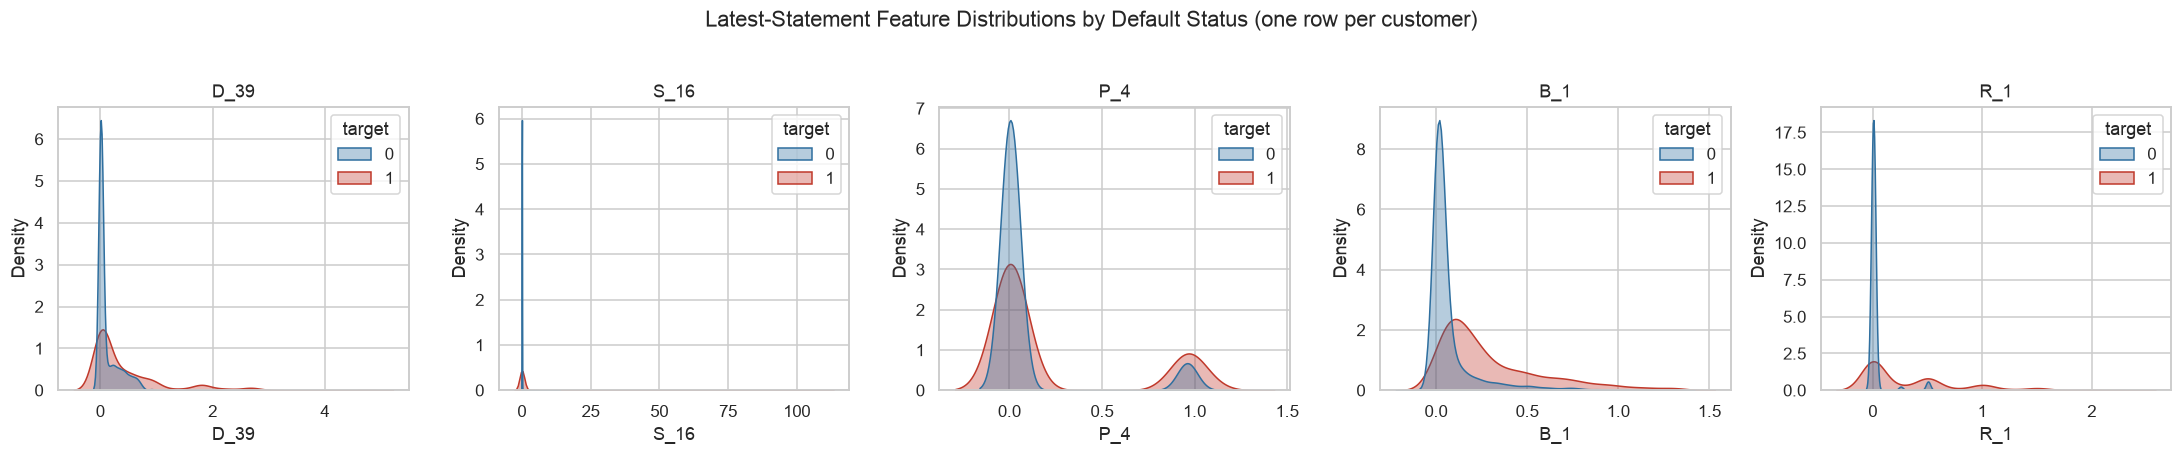

In [28]:
fig, axes = plt.subplots(1, len(chosen_features), figsize=(4 * len(chosen_features), 4), sharey=False)
for ax, feat in zip(axes, chosen_features):
    sns.kdeplot(
        data=latest_per_customer, x=feat, hue="target",
        common_norm=False, fill=True, alpha=0.35, ax=ax,
        palette={0: "#2f6f9f", 1: "#c0392b"},
    )
    ax.set_title(feat)
fig.suptitle("Latest-Statement Feature Distributions by Default Status (one row per customer)", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "feature_distributions_by_target.png"))
plt.show()


**Interpretation:** even with this quick, customer-deduplicated view, several of these
representative features (notably the payment- and balance-related ones) show visibly
different distributions between defaulters and non-defaulters at their most recent
statement — a reasonable early signal that customer-level aggregation of these features
will carry predictive signal in Phase 2. This is illustrative, not exhaustive; a full
univariate screen belongs in feature engineering, not here.


### Categorical features

Cardinality, most common categories, and missingness for the object-dtype columns
identified in Section 4.


In [29]:
for col in categorical_like_cols:
    n_unique = sample_df[col].nunique(dropna=True)
    miss = missing_pct.get(col, float("nan"))
    top_vals = sample_df[col].value_counts(dropna=True).head(5)
    print(f"--- {col} --- unique={n_unique}, missing={miss:.2f}%")
    print(top_vals.to_string())
    print()


--- D_63 --- unique=6, missing=0.00%
D_63
CO    44934
CR    10000
CL     4878
XZ      292
XM       88

--- D_64 --- unique=4, missing=3.93%
D_64
O     31977
U     16659
R      8891
-1      383



## 7. Temporal / Longitudinal Behavior

**Question:** How do financial variables move across a customer's statement history, and
why would summarizing that history (mean, min, max, std, first, last, change) be useful
input for a customer-level model later?

This section is illustrative — it does **not** build the full aggregation pipeline, which
is Phase 2 scope.


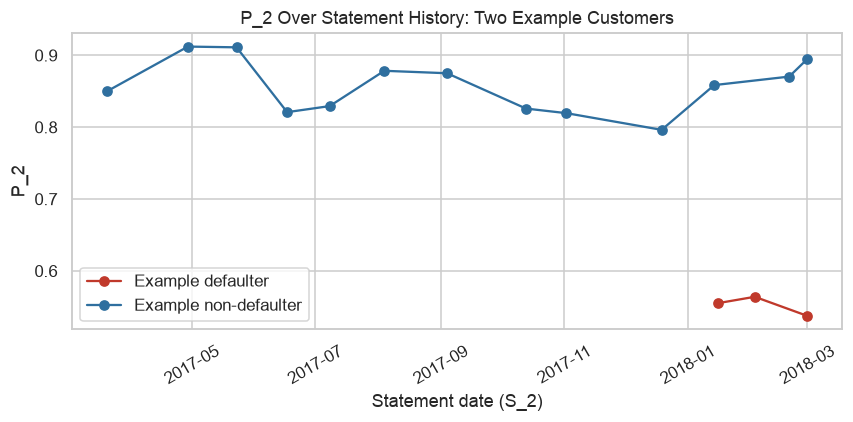

In [30]:
default_customers = latest_per_customer.loc[latest_per_customer["target"] == 1, ID_COL]
nondefault_customers = latest_per_customer.loc[latest_per_customer["target"] == 0, ID_COL]
example_default_cust = default_customers.iloc[0]
example_nondefault_cust = nondefault_customers.iloc[0]

TEMPORAL_FEATURE = "P_2"

fig, ax = plt.subplots(figsize=(8, 4))
for cust, label, color in [
    (example_default_cust, "Example defaulter", "#c0392b"),
    (example_nondefault_cust, "Example non-defaulter", "#2f6f9f"),
]:
    hist = sample_df[sample_df[ID_COL] == cust].sort_values(DATE_COL)
    ax.plot(hist[DATE_COL], hist[TEMPORAL_FEATURE], marker="o", label=label, color=color)

ax.set_title(f"{TEMPORAL_FEATURE} Over Statement History: Two Example Customers")
ax.set_xlabel("Statement date (S_2)")
ax.set_ylabel(TEMPORAL_FEATURE)
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "temporal_example_customers.png"))
plt.show()


In [31]:
# Why customer-level aggregation matters: per-customer summary stats of one feature,
# computed on the sample, illustrate the kind of columns Phase 2 feature engineering will
# generate -- without building that pipeline here.
agg_preview = (
    sample_df.sort_values(DATE_COL)
    .groupby(ID_COL)[TEMPORAL_FEATURE]
    .agg(mean="mean", min="min", max="max", std="std", first="first", last="last")
)
agg_preview["change_first_to_last"] = agg_preview["last"] - agg_preview["first"]
agg_preview.head()


,mean,min,max,std,first,last,change_first_to_last
customer_ID,,,,,,,
000cc98607442c5074d368870a7fa3cb1634147af647f1aec9c99175aaf0c7fa,0.175368,0.046369,0.255035,0.074685,0.200289,0.255035,0.054746
000f8675ede66cc6affd4c048db11a00246d7ee623f453aae22d693c4a82f832,0.779492,0.715083,0.802666,0.035927,0.715083,0.799201,0.084118
00562bc943163345c838cb0eaf50656c16af09b9991f60a98221bfe7e3512937,0.463296,0.397252,0.491396,0.030810,0.491396,0.476867,-0.014529
0056d751c3a977255a3bd8beeb72c625e6d09388f432eb8a728d3a283b80f083,0.351608,0.284631,0.399202,0.038420,0.351413,0.363112,0.011699
00582971eb87cf0bb643ed23cc0e0b3ad475379513c4601d4d079f9684c57fcb,0.496485,0.414248,0.527685,0.036167,0.453321,0.527685,0.074364


**Interpretation:** the two example trajectories show the same statement-level feature can
trend very differently across a customer's history — a snapshot from a single statement
would miss that trend entirely. This is the concrete motivation for Phase 2's customer-level
feature engineering: statistics like mean/min/max/std capture the overall level and
volatility of a feature, while first/last/change-from-first-to-last capture trend and
recency, which a static, single-statement view cannot.


## Summary

This notebook is diagnostic only — no features were dropped, no imputation was applied, and
no model was trained. Findings here (dataset shape, class imbalance, missingness structure,
dtype nuances, and the value of temporal aggregation) directly motivate the customer-level
feature engineering pipeline planned for Phase 2.
